# Analisis de datos | Riesgo de credito

Base de solicitudes de un banco aleman (German Credit). Quiero analizar la base y armar un modelo que reproduzca el criterio del banco para aprobar o rechazar. Sigo CRISP-DM.

## 1. Comprension del negocio

1000 solicitudes, 20 variables y la decision del banco. La muestra es chica para tantas variables, asi que reviso information value y correlaciones antes de modelar.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

## 2. Comprension de los datos

Cargo el Excel, renombro las columnas y armo el target. El decodificador `german_clean.docx` da el significado de cada codigo.

In [2]:
nombres = {
    1: "checking_account_status", 2: "duration_months", 3: "credit_history",
    4: "purpose", 5: "credit_amount", 6: "savings_account", 7: "employment_since",
    8: "installment_rate", 9: "personal_status_sex", 10: "other_debtors",
    11: "residence_since", 12: "property", 13: "age_years", 14: "other_installment_plans",
    15: "housing", 16: "existing_credits", 17: "job", 18: "liable_people",
    19: "telephone", 20: "foreign_worker",
}
df = pd.read_excel("data/Base_Clientes_Alemanes.xlsx", sheet_name="Raw data")
df = df.rename(columns=nombres).drop(columns=["Cliente"])
df["target"] = df["Rechazo"].map({1: "aprobado", 2: "rechazado"})
df = df.drop(columns=["Rechazo"])
df.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,residence_since,property,age_years,other_installment_plans,housing,existing_credits,job,liable_people,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201,aprobado
1,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201,aprobado
2,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201,aprobado
3,A14,36,A32,A46,9055,A65,A73,2,A93,A101,4,A124,35,A143,A153,1,A172,2,A192,A201,aprobado
4,A14,24,A32,A42,2835,A63,A75,3,A93,A101,4,A122,53,A143,A152,1,A173,1,A191,A201,aprobado


In [3]:
print(df.shape)
print(df["target"].value_counts())
print("nulos:", df.isnull().sum().sum())

(1000, 21)
target
aprobado     700
rechazado    300
Name: count, dtype: int64
nulos: 0


Sin nulos. Target desbalanceado (700/300): la accuracy enganha, miro el recall de la clase rechazo.

In [4]:
decodificacion = {
    "checking_account_status": {"A11": "< 0 DM", "A12": "0-200 DM", "A13": ">= 200 DM", "A14": "sin cuenta"},
    "credit_history": {"A30": "sin creditos", "A31": "todo pago aca", "A32": "vigentes al dia", "A33": "atrasos pasados", "A34": "cuenta critica"},
    "purpose": {"A40": "auto nuevo", "A41": "auto usado", "A42": "muebles", "A43": "radio/TV", "A44": "electrodomesticos", "A45": "reparaciones", "A46": "educacion", "A47": "vacaciones", "A48": "recapacitacion", "A49": "negocio", "A410": "otros"},
    "savings_account": {"A61": "< 100 DM", "A62": "100-500 DM", "A63": "500-1000 DM", "A64": ">= 1000 DM", "A65": "sin ahorros"},
    "employment_since": {"A71": "desempleado", "A72": "< 1 anio", "A73": "1-4 anios", "A74": "4-7 anios", "A75": ">= 7 anios"},
    "personal_status_sex": {"A91": "hombre div/sep", "A92": "mujer div/casada", "A93": "hombre soltero", "A94": "hombre casado", "A95": "mujer soltera"},
    "other_debtors": {"A101": "ninguno", "A102": "co-solicitante", "A103": "garante"},
    "property": {"A121": "inmueble", "A122": "seguro de vida", "A123": "auto u otro", "A124": "sin propiedad"},
    "other_installment_plans": {"A141": "banco", "A142": "comercios", "A143": "ninguno"},
    "housing": {"A151": "alquila", "A152": "propia", "A153": "gratuita"},
    "job": {"A171": "no calif. no residente", "A172": "no calif. residente", "A173": "calificado", "A174": "muy calificado"},
    "telephone": {"A191": "no", "A192": "si"},
    "foreign_worker": {"A201": "si", "A202": "no"},
}
df_dec = df.copy()
for col, mapa in decodificacion.items():
    df_dec[col] = df_dec[col].map(mapa)
df_dec.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,residence_since,property,age_years,other_installment_plans,housing,existing_credits,job,liable_people,telephone,foreign_worker,target
0,< 0 DM,6,cuenta critica,radio/TV,1169,sin ahorros,>= 7 anios,4,hombre soltero,ninguno,4,inmueble,67,ninguno,propia,2,calificado,1,si,si,aprobado
1,sin cuenta,12,cuenta critica,educacion,2096,< 100 DM,4-7 anios,2,hombre soltero,ninguno,3,inmueble,49,ninguno,propia,1,no calif. residente,2,no,si,aprobado
2,< 0 DM,42,vigentes al dia,muebles,7882,< 100 DM,4-7 anios,2,hombre soltero,garante,4,seguro de vida,45,ninguno,gratuita,1,calificado,2,no,si,aprobado
3,sin cuenta,36,vigentes al dia,educacion,9055,sin ahorros,1-4 anios,2,hombre soltero,ninguno,4,sin propiedad,35,ninguno,gratuita,1,no calif. residente,2,si,si,aprobado
4,sin cuenta,24,vigentes al dia,muebles,2835,500-1000 DM,>= 7 anios,3,hombre soltero,ninguno,4,seguro de vida,53,ninguno,propia,1,calificado,1,no,si,aprobado


### Variables numericas

In [5]:
num_cols = ["duration_months", "credit_amount", "installment_rate", "residence_since",
            "age_years", "existing_credits", "liable_people"]
cat_cols = [c for c in df.columns if c not in num_cols + ["target"]]
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
duration_months,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
credit_amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
installment_rate,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
residence_since,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
age_years,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
existing_credits,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
liable_people,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0


Monto y plazo son las de mayor recorrido; el resto, rangos cortos casi ordinales.

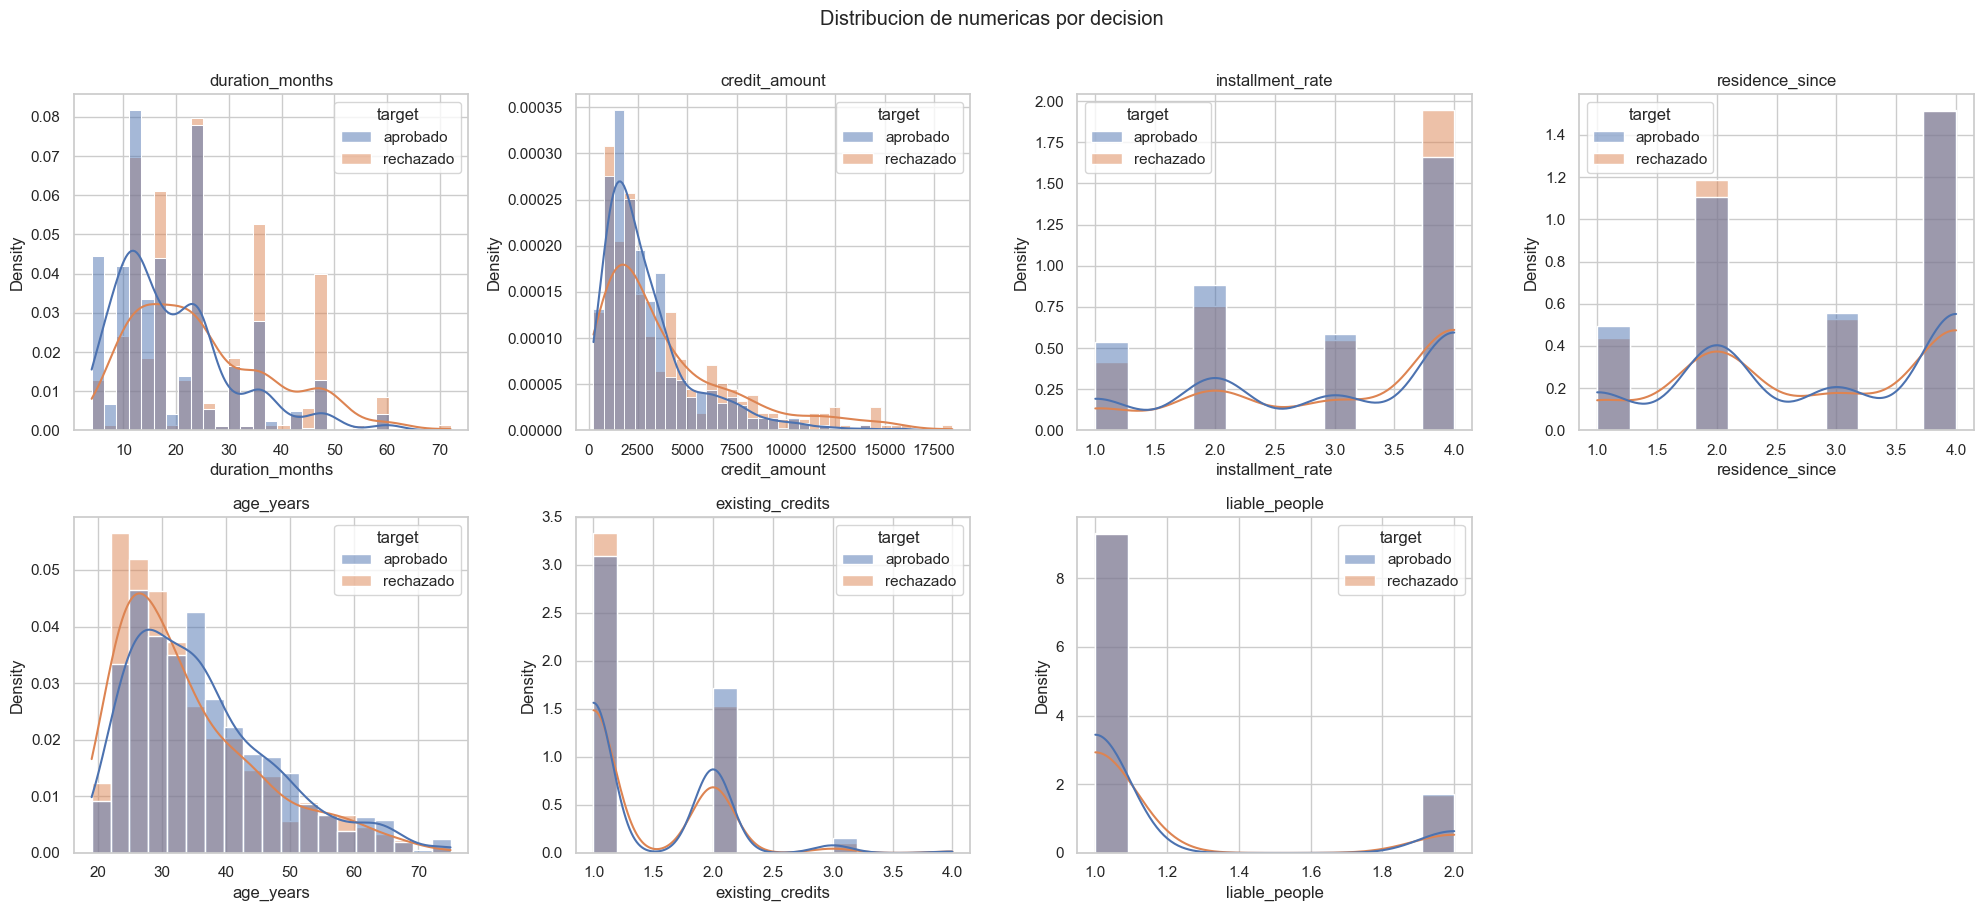

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.ravel()
for ax, c in zip(axes, num_cols):
    sns.histplot(data=df_dec, x=c, hue="target", kde=True, ax=ax,
                 stat="density", common_norm=False, alpha=0.5)
    ax.set_title(c)
axes[-1].axis("off")
plt.suptitle("Distribucion de numericas por decision", y=1.01)
plt.tight_layout()
plt.show()

Plazo y monto se corren hacia los rechazados (mas largos, mas altos); las demas casi se superponen.

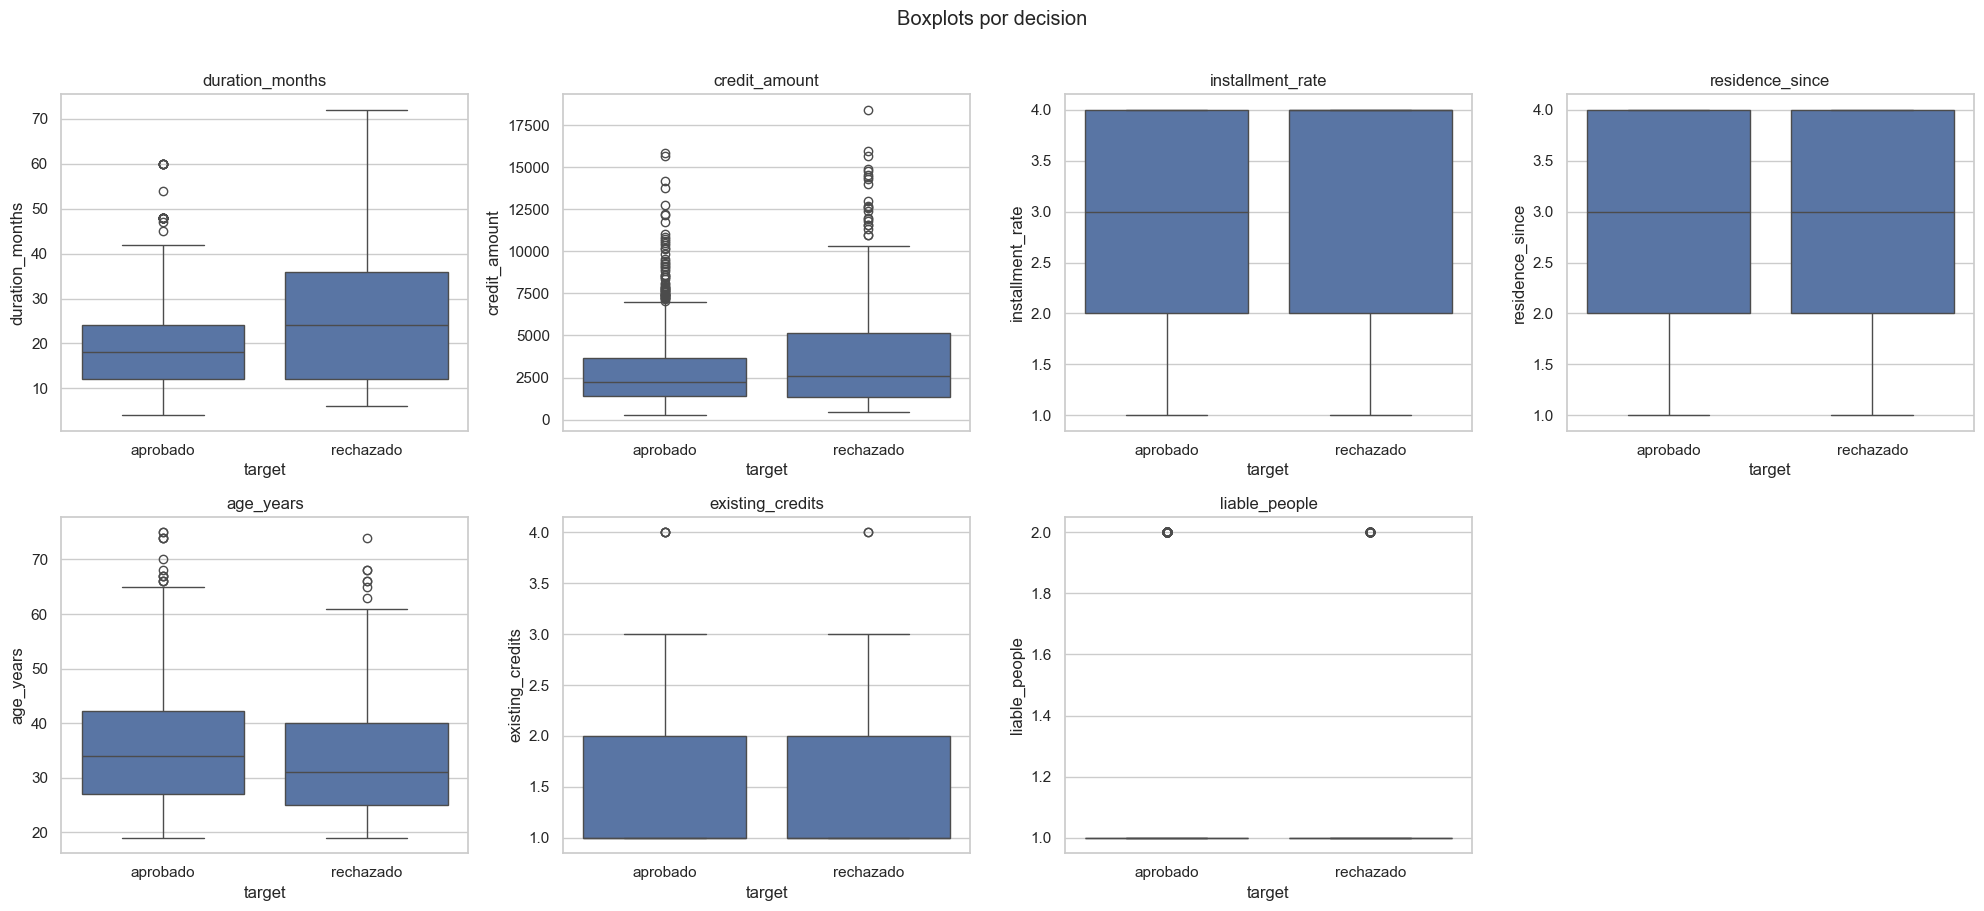

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.ravel()
for ax, c in zip(axes, num_cols):
    sns.boxplot(data=df_dec, x="target", y=c, ax=ax)
    ax.set_title(c)
axes[-1].axis("off")
plt.suptitle("Boxplots por decision", y=1.01)
plt.tight_layout()
plt.show()

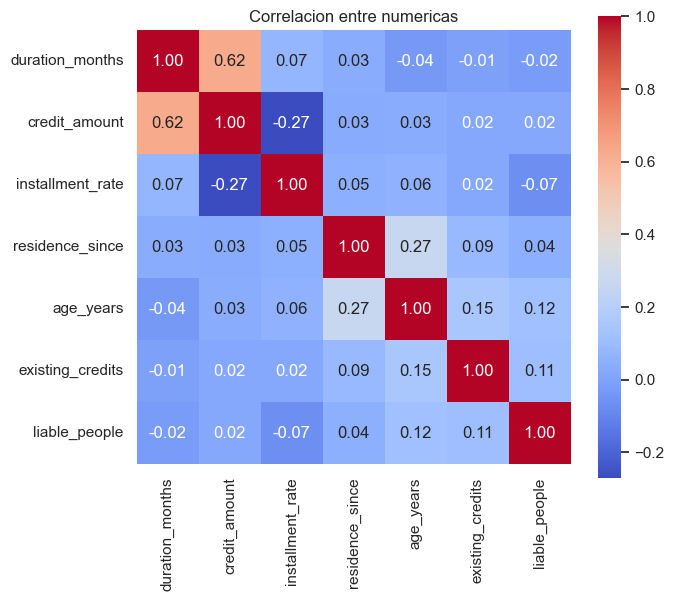

In [8]:
plt.figure(figsize=(7, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlacion entre numericas")
plt.show()

### Variables categoricas

Tasa de rechazo por categoria: donde se despega del 30% global, la variable aporta.

/var/folders/pp/2w01y9pd6px1lfx6rs9vs5p00000gp/T/ipykernel_18513/1607432274.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tab.values, y=tab.index, ax=ax, palette="rocket")
/var/folders/pp/2w01y9pd6px1lfx6rs9vs5p00000gp/T/ipykernel_18513/1607432274.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tab.values, y=tab.index, ax=ax, palette="rocket")
/var/folders/pp/2w01y9pd6px1lfx6rs9vs5p00000gp/T/ipykernel_18513/1607432274.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tab.values, y=tab.index, ax=ax, palette="rocket")
/var/fo

/var/folders/pp/2w01y9pd6px1lfx6rs9vs5p00000gp/T/ipykernel_18513/1607432274.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tab.values, y=tab.index, ax=ax, palette="rocket")


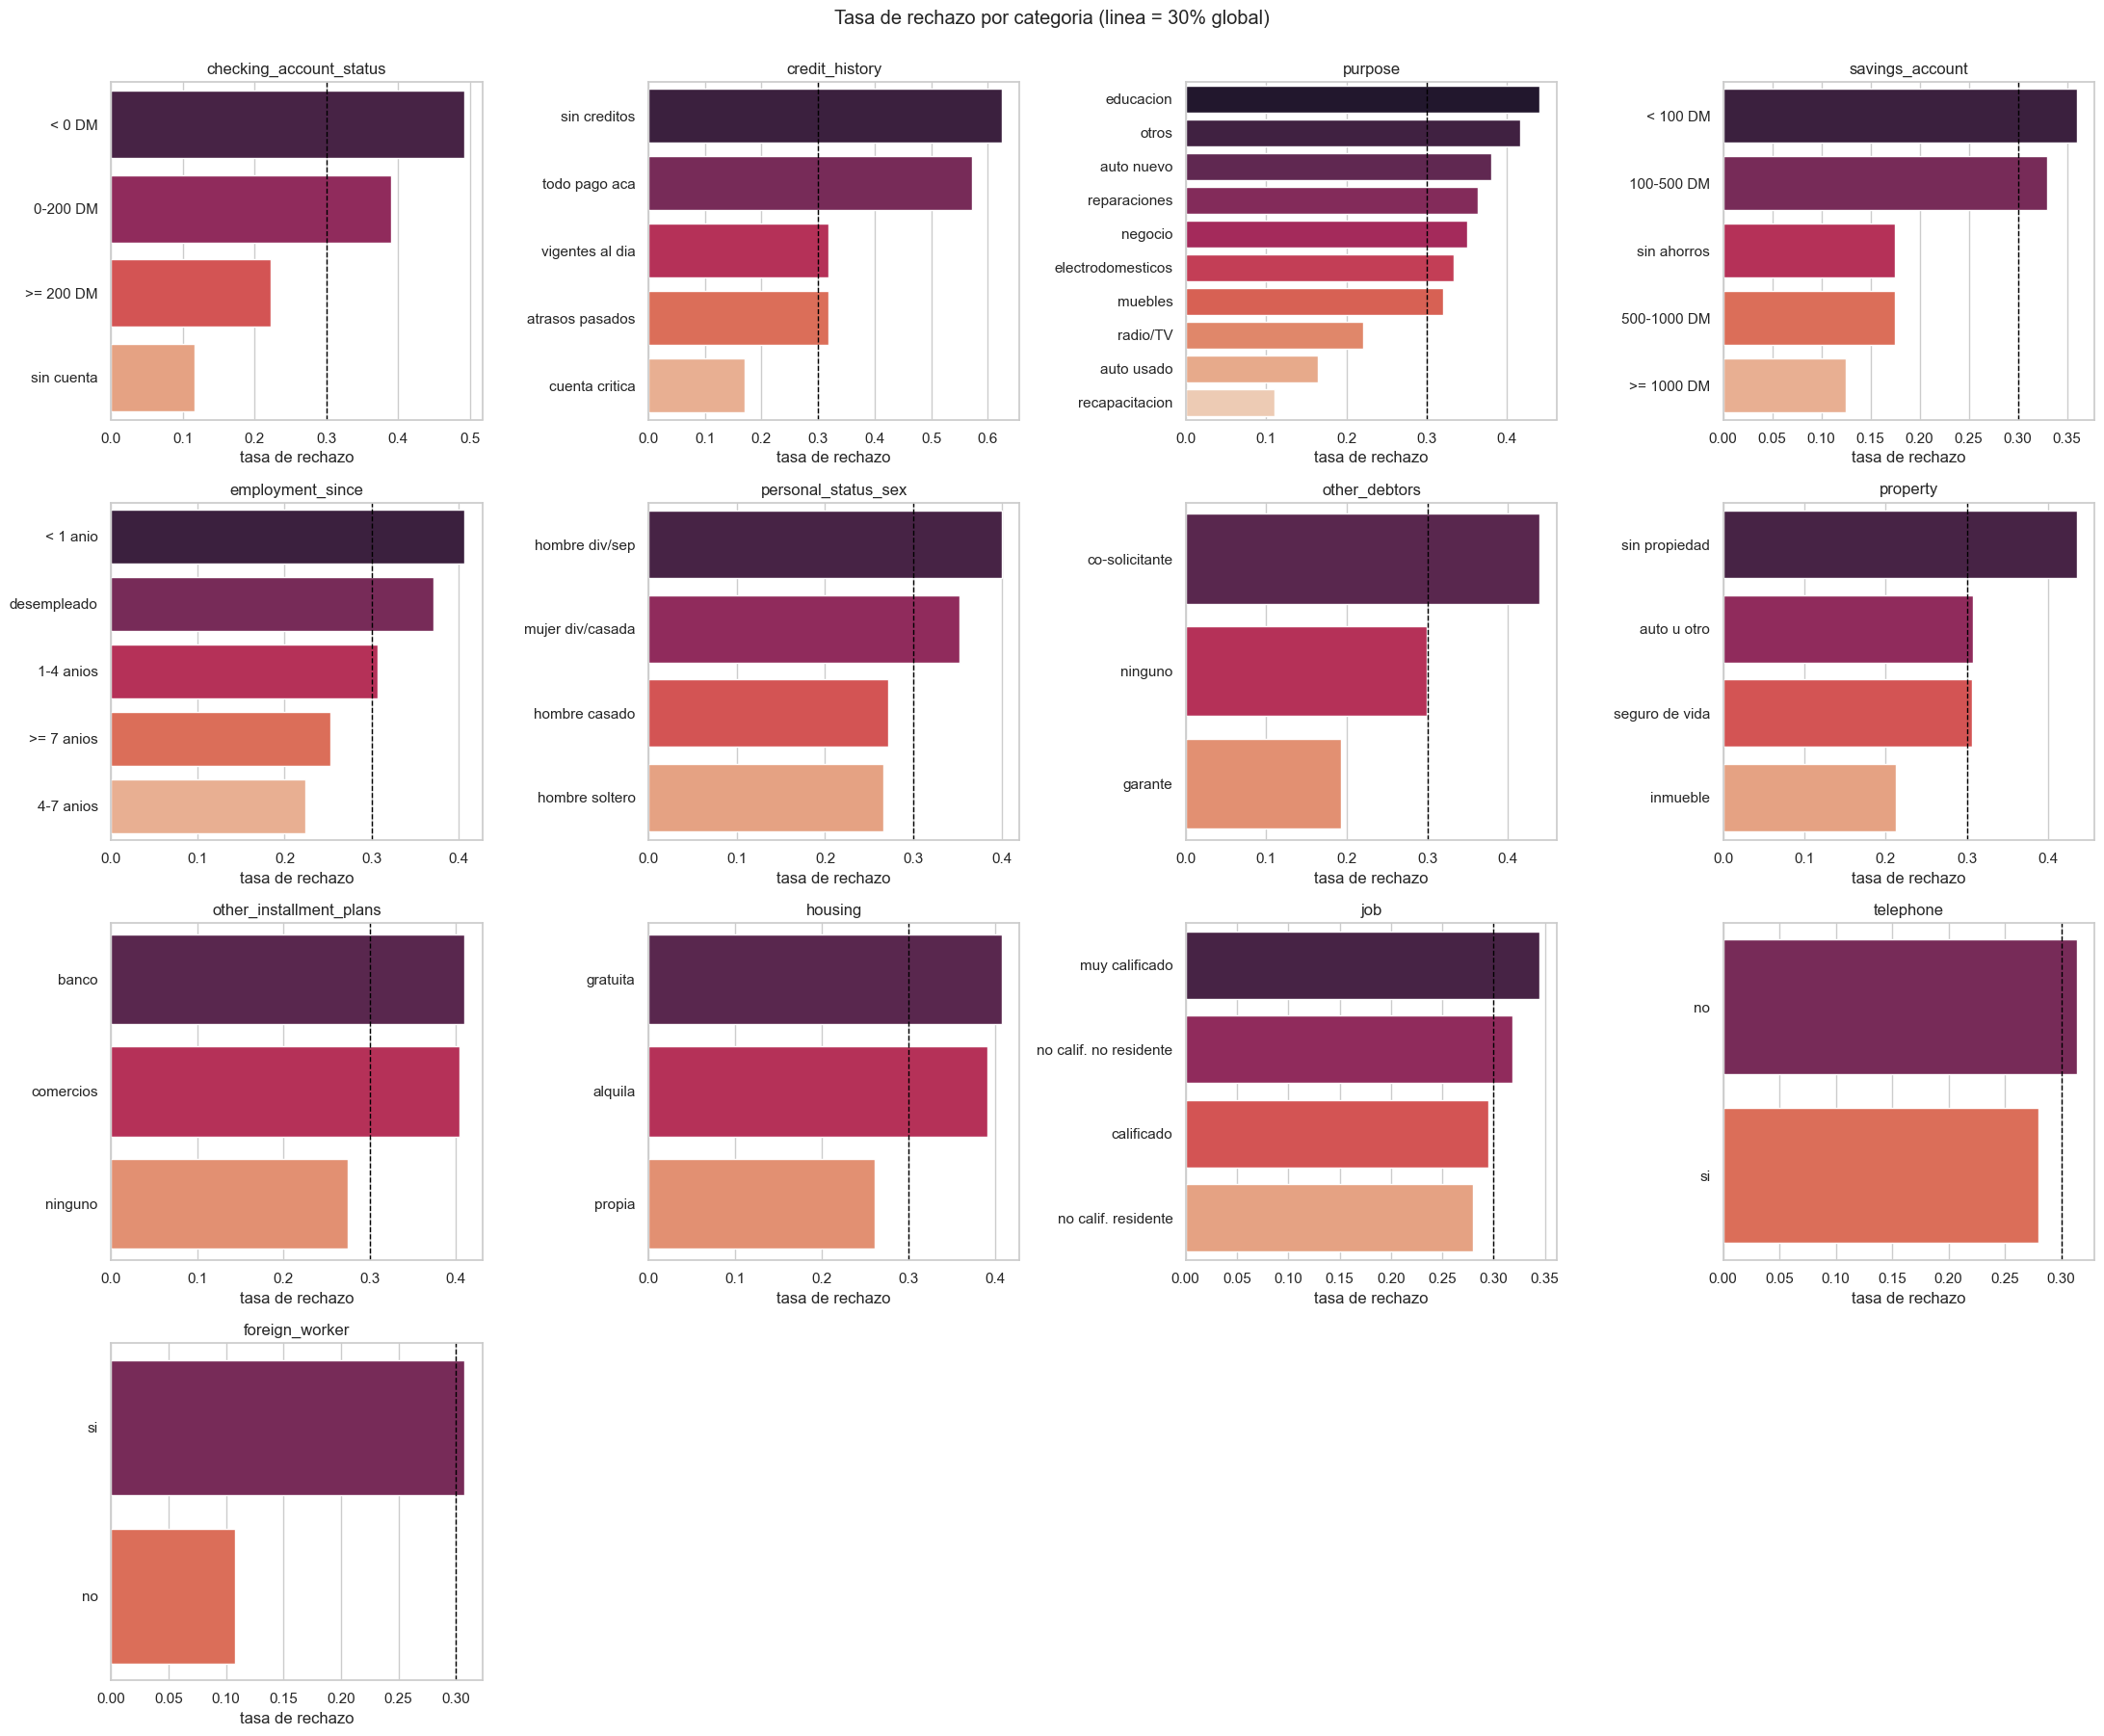

In [9]:
fig, axes = plt.subplots(4, 4, figsize=(22, 18))
axes = axes.ravel()
base_rate = (df["target"] == "rechazado").mean()
for ax, c in zip(axes, cat_cols):
    tab = (df_dec.assign(es_rechazo=df["target"].eq("rechazado"))
           .groupby(c)["es_rechazo"].mean().sort_values(ascending=False))
    sns.barplot(x=tab.values, y=tab.index, ax=ax, palette="rocket")
    ax.axvline(base_rate, color="black", linestyle="--", linewidth=1)
    ax.set_title(c)
    ax.set_xlabel("tasa de rechazo")
    ax.set_ylabel("")
for k in range(len(cat_cols), len(axes)):
    axes[k].axis("off")
plt.suptitle("Tasa de rechazo por categoria (linea = 30% global)", y=1.0)
plt.tight_layout()
plt.show()

La cuenta corriente separa lo mas claro (sin cuenta casi no rechaza, en negativo rechaza mucho); historial, ahorros y empleo tambien. Telefono o trabajador extranjero casi no.

### Representatividad de las categorias

Antes del information value miro otra cosa que advierte la consigna: variables poco representativas por bajo tamano muestral. Una categoria con muy pocos casos puede mostrar una tasa de rechazo llamativa que en realidad es ruido. Cuento la frecuencia de cada categoria y marco como raras las que quedan por debajo del 2% de la muestra (menos de 20 casos).

In [10]:
umbral_raro = int(0.02 * len(df))
filas = []
for c in cat_cols:
    vc = df_dec[c].value_counts()
    for categoria, n in vc.items():
        filas.append({"variable": c, "categoria": categoria, "n": int(n),
                      "pct": round(100 * n / len(df), 1), "raro": n < umbral_raro})
frec = pd.DataFrame(filas).sort_values(["variable", "n"], ascending=[True, False]).reset_index(drop=True)
print("Umbral de rareza:", umbral_raro, "casos (2% de la muestra)")
print("Categorias raras:", int(frec["raro"].sum()), "de", len(frec))
frec[frec["raro"]].sort_values("n").reset_index(drop=True)

Umbral de rareza: 20 casos (2% de la muestra)
Categorias raras: 3 de 54


,variable,categoria,n,pct,raro
0,purpose,recapacitacion,9,0.9,True
1,purpose,electrodomesticos,12,1.2,True
2,purpose,otros,12,1.2,True


/var/folders/pp/2w01y9pd6px1lfx6rs9vs5p00000gp/T/ipykernel_18513/1730357297.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sub["n"].values, y=sub["categoria"].values, ax=ax, palette=colores)
/var/folders/pp/2w01y9pd6px1lfx6rs9vs5p00000gp/T/ipykernel_18513/1730357297.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sub["n"].values, y=sub["categoria"].values, ax=ax, palette=colores)
/var/folders/pp/2w01y9pd6px1lfx6rs9vs5p00000gp/T/ipykernel_18513/1730357297.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sub["n"].values, y=su

/var/folders/pp/2w01y9pd6px1lfx6rs9vs5p00000gp/T/ipykernel_18513/1730357297.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sub["n"].values, y=sub["categoria"].values, ax=ax, palette=colores)


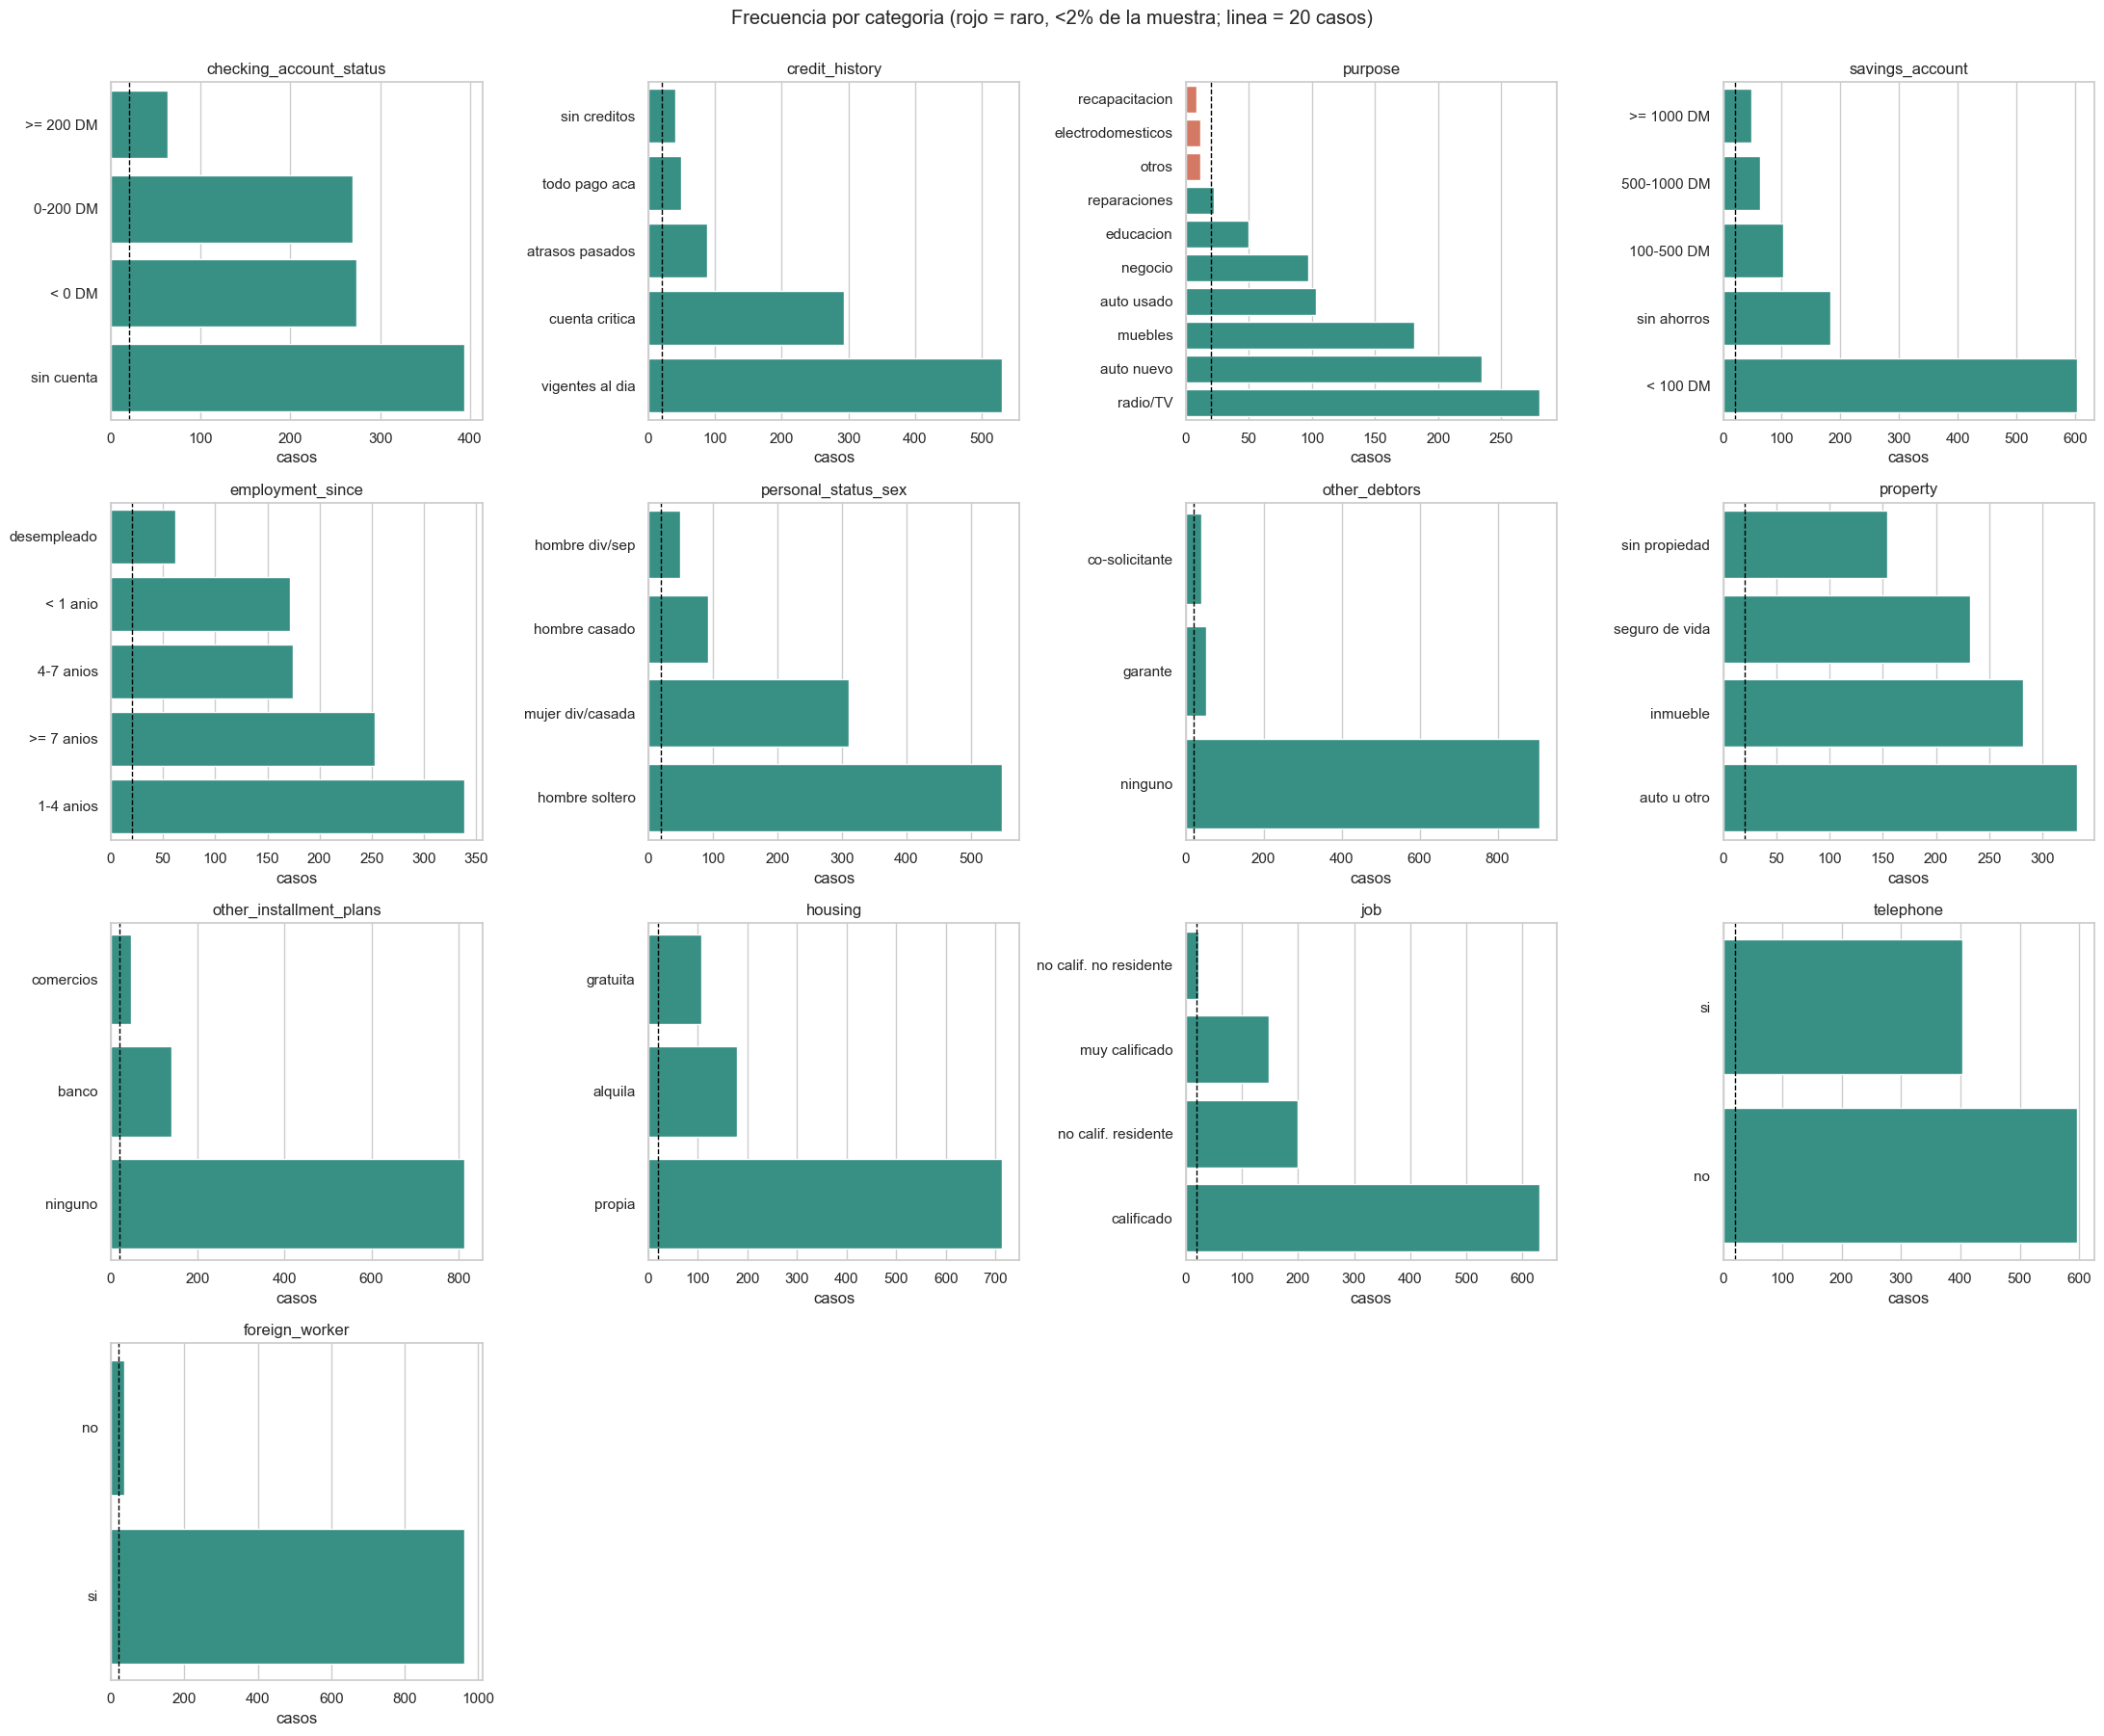

In [11]:
fig, axes = plt.subplots(4, 4, figsize=(22, 18))
axes = axes.ravel()
for ax, c in zip(axes, cat_cols):
    sub = frec[frec["variable"] == c].sort_values("n")
    colores = ["#e76f51" if r else "#2a9d8f" for r in sub["raro"]]
    sns.barplot(x=sub["n"].values, y=sub["categoria"].values, ax=ax, palette=colores)
    ax.axvline(umbral_raro, color="black", linestyle="--", linewidth=1)
    ax.set_title(c)
    ax.set_xlabel("casos")
    ax.set_ylabel("")
for k in range(len(cat_cols), len(axes)):
    axes[k].axis("off")
plt.suptitle("Frecuencia por categoria (rojo = raro, <2% de la muestra; linea = 20 casos)", y=1.0)
plt.tight_layout()
plt.show()

Tres categorias quedan por debajo del umbral, todas dentro de proposito: recapacitacion (A48, 9 casos), electrodomesticos (A44) y otros (A410), las tres por debajo del 1.5% de la muestra. Su tasa de rechazo en el grafico anterior hay que tomarla con pinzas: con tan pocos casos un par de solicitudes mueven el numero. No las tiro, pero las leo como poco representativas; queda como aviso de que proposito, aunque tenga information value medio, lo apoya en categorias finas. Dejo que sea el information value el que decida si cada variable entera aporta o no.

### Information value

La consigna pide mirar el information value. Lo calculo por variable (numericas en deciles); regla: <0.02 inutil, 0.1-0.3 medio, >0.3 fuerte.

In [12]:
def iv(serie, y_bad):
    d = pd.DataFrame({"x": serie, "bad": y_bad})
    g = d.groupby("x", observed=True)["bad"].agg(["size", "sum"])
    g.columns = ["n", "malos"]
    g["buenos"] = g["n"] - g["malos"]
    dist_b = (g["buenos"] / g["buenos"].sum()).replace(0, 1e-6)
    dist_m = (g["malos"] / g["malos"].sum()).replace(0, 1e-6)
    return float(((dist_b - dist_m) * np.log(dist_b / dist_m)).sum())

y_bad = (df["target"] == "rechazado").astype(int)
filas = []
for c in cat_cols:
    filas.append({"variable": c, "IV": iv(df[c], y_bad)})
for c in num_cols:
    filas.append({"variable": c, "IV": iv(pd.qcut(df[c], 10, duplicates="drop"), y_bad)})
iv_tab = pd.DataFrame(filas).sort_values("IV", ascending=False).reset_index(drop=True)
iv_tab

,variable,IV
0,checking_account_status,0.666012
1,credit_history,0.293234
2,duration_months,0.246542
3,savings_account,0.196010
4,purpose,0.169195
5,credit_amount,0.113637
6,property,0.112638
7,age_years,0.100622
8,employment_since,0.086434
9,housing,0.083293


/var/folders/pp/2w01y9pd6px1lfx6rs9vs5p00000gp/T/ipykernel_18513/899427952.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=iv_tab, x="IV", y="variable", palette="viridis")


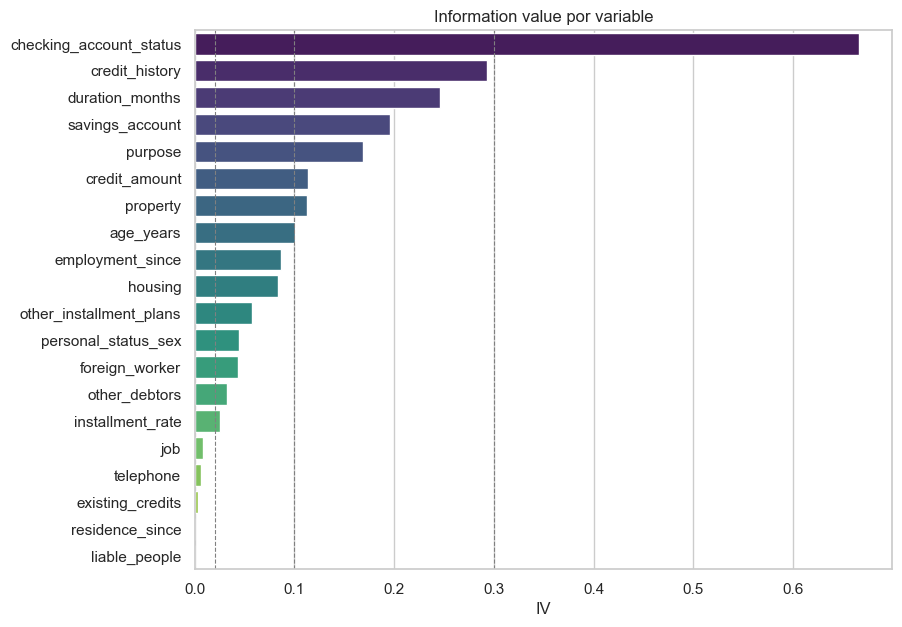

In [13]:
plt.figure(figsize=(9, 7))
sns.barplot(data=iv_tab, x="IV", y="variable", palette="viridis")
for x in [0.02, 0.1, 0.3]:
    plt.axvline(x, color="grey", linestyle="--", linewidth=0.8)
plt.title("Information value por variable")
plt.ylabel("")
plt.show()

La cuenta corriente domina, seguida por historial, plazo, ahorros, monto y proposito. El resto cae en "inutil": las variables poco relevantes que adelantaba la consigna.

### Correlacion de las numericas

Cross-check del IV: confirmo que plazo y monto van con el rechazo (positivo) y la edad al reves, todo moderado.

In [14]:
corr_tab = (df[num_cols].apply(lambda s: s.corr(y_bad))
            .sort_values(key=abs, ascending=False).round(3).reset_index())
corr_tab.columns = ["variable", "corr_con_rechazo"]
corr_tab

,variable,corr_con_rechazo
0,duration_months,0.215
1,credit_amount,0.155
2,age_years,-0.091
3,installment_rate,0.072
4,existing_credits,-0.046
5,liable_people,-0.003
6,residence_since,0.003


### Vista multivariada

Monto vs plazo por decision: los rechazados tienden a la esquina de plazos largos y montos altos, sin ser una regla dura.

In [15]:
fig = px.scatter(df_dec, x="duration_months", y="credit_amount", color="target",
                 opacity=0.6, marginal_x="box", marginal_y="box",
                 color_discrete_map={"aprobado": "#2a9d8f", "rechazado": "#e76f51"},
                 title="Monto vs plazo segun la decision")
fig.update_traces(marker_size=6)
fig

In [16]:
dfp = df_dec.copy()
dfp["target_code"] = (df["target"] == "rechazado").astype(int)
fig = px.parallel_coordinates(dfp, dimensions=["duration_months", "credit_amount", "age_years", "installment_rate"],
                              color="target_code",
                              color_continuous_scale=px.colors.diverging.RdYlGn_r,
                              title="Coordenadas paralelas (rojo = rechazado)")
fig

## 3. Preparacion de los datos

Dummies para las categoricas, split 70/30 estratificado y escalo las numericas con el scaler ajustado solo en train.

In [17]:
y = (df["target"] == "rechazado").astype(int)
X = pd.get_dummies(df.drop(columns=["target"]), columns=cat_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_SEED)

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(X_train.shape, X_test.shape)
print("tasa rechazo train/test:", round(y_train.mean(), 3), round(y_test.mean(), 3))

(700, 61) (300, 61)
tasa rechazo train/test: 0.3 0.3


Se conserva el ~0.30 en train y test. Uso `class_weight="balanced"` para que no ignoren la clase rechazo.

## 4. Modelado

Pruebo regresion logistica, KNN y random forest. Comparo primero con validacion cruzada de 5 folds usando recall de la clase rechazo.

In [18]:
modelos = {
    "LogReg": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "RandomForest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_SEED),
}
cv = {n: cross_val_score(m, X_train, y_train, cv=5, scoring="recall").mean()
      for n, m in modelos.items()}
pd.Series(cv, name="cv_recall_rechazo").sort_values(ascending=False).round(3)

LogReg          0.681
RandomForest    0.357
KNN             0.200
Name: cv_recall_rechazo, dtype: float64

In [19]:
filas = []
fitted = {}
for n, m in modelos.items():
    m.fit(X_train, y_train)
    fitted[n] = m
    pred = m.predict(X_test)
    rep = classification_report(y_test, pred, output_dict=True)
    filas.append({"modelo": n, "accuracy": rep["accuracy"],
                  "recall_rechazo": rep["1"]["recall"],
                  "precision_rechazo": rep["1"]["precision"],
                  "f1_rechazo": rep["1"]["f1-score"]})
tabla = pd.DataFrame(filas).sort_values("recall_rechazo", ascending=False).round(3).reset_index(drop=True)
tabla

,modelo,accuracy,recall_rechazo,precision_rechazo,f1_rechazo
0,LogReg,0.730,0.767,0.535,0.630
1,RandomForest,0.750,0.356,0.653,0.460
2,KNN,0.743,0.289,0.667,0.403


LogReg y random forest detectan mejor la clase rechazo que KNN, a costa de algo de accuracy. Para un banco vale: dejar pasar un mal cliente cuesta mas que rechazar a uno bueno.

### Variables mas importantes

/var/folders/pp/2w01y9pd6px1lfx6rs9vs5p00000gp/T/ipykernel_18513/1961439365.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp.tail(15).values, y=imp.tail(15).index, palette="viridis")


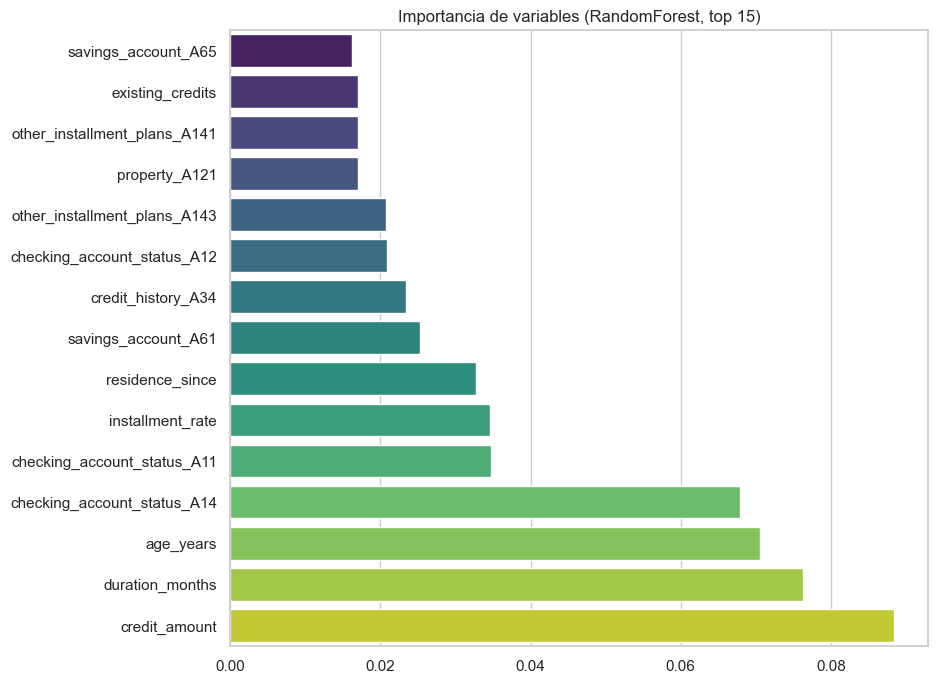

In [20]:
rf = fitted["RandomForest"]
imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values()
plt.figure(figsize=(9, 8))
sns.barplot(x=imp.tail(15).values, y=imp.tail(15).index, palette="viridis")
plt.title("Importancia de variables (RandomForest, top 15)")
plt.ylabel("")
plt.show()

Encabezan de nuevo cuenta corriente, monto, plazo, historial y ahorros: dos miradas distintas, el mismo nucleo.

## 5. Evaluacion

Reporte por clase y matriz de confusion del mejor modelo por recall.

In [21]:
mejor = tabla.iloc[0]["modelo"]
pred = fitted[mejor].predict(X_test)
print("Mejor modelo:", mejor)
print(classification_report(y_test, pred, target_names=["aprobado", "rechazado"]))

Mejor modelo: LogReg
              precision    recall  f1-score   support

    aprobado       0.88      0.71      0.79       210
   rechazado       0.53      0.77      0.63        90

    accuracy                           0.73       300
   macro avg       0.71      0.74      0.71       300
weighted avg       0.77      0.73      0.74       300



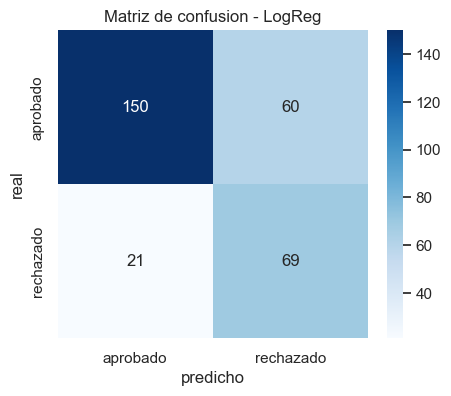

In [22]:
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["aprobado", "rechazado"], yticklabels=["aprobado", "rechazado"])
plt.title(f"Matriz de confusion - {mejor}")
plt.ylabel("real")
plt.xlabel("predicho")
plt.show()

El cuadrante caro es el de rechazados que el modelo aprueba; el modelo balanceado lo achica a costa de rechazar algunos buenos de mas.

## 6. Conclusiones

El criterio es reproducible e interpretable: pesan sobre todo cuenta corriente, historial, plazo, monto, ahorros y proposito; con media docena de variables se reconstruye casi todo, como anticipaba la consigna. Como aprobar a un mal cliente sale mas caro, miro el recall de la clase rechazo, no la accuracy.